In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = DecisionTreeClassifier(criterion='gini', random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0
Accuracy: 1.0


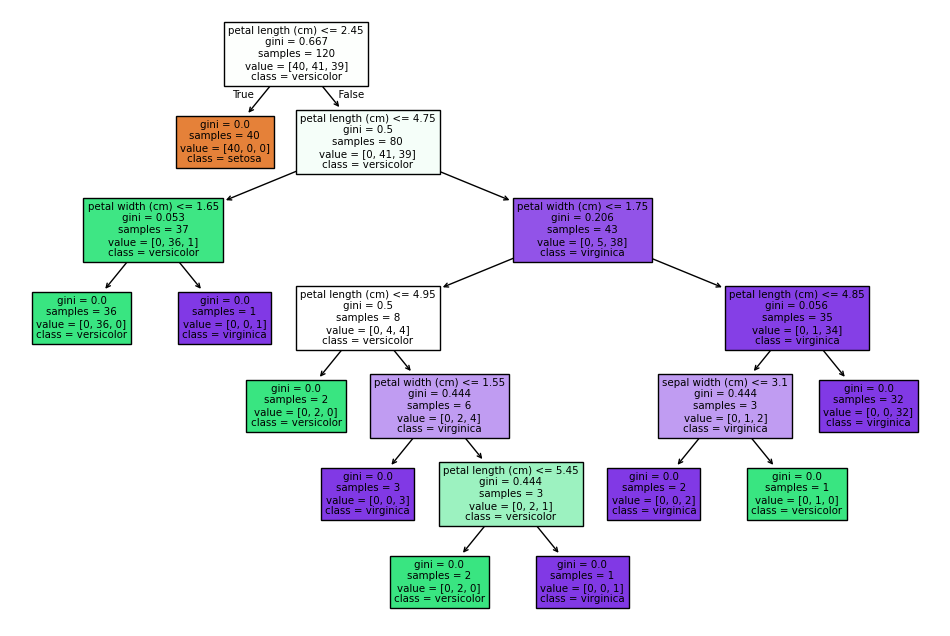

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

Decision Tree Classification on Diabetes Dataset

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Step 2: Upload Dataset

In [9]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


Step 3: Load Dataset

In [11]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Step 4: Dataset Information

df.info()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               769 non-null    int64  
 1   Glucose                   769 non-null    int64  
 2   BloodPressure             769 non-null    int64  
 3   SkinThickness             769 non-null    int64  
 4   Insulin                   769 non-null    int64  
 5   BMI                       769 non-null    float64
 6   DiabetesPedigreeFunction  769 non-null    float64
 7   Age                       769 non-null    int64  
 8   Outcome                   769 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.2 KB


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,3.841352,120.858257,69.106632,20.550065,79.695709,31.990507,0.471672,33.227568,0.348505
std,3.368946,31.967626,19.343229,15.946293,115.204894,7.879235,0.331161,11.758373,0.476807
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,29.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.000000,36.600000,0.626000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
df.shape

(769, 9)

Step 5: Check Missing Values

In [15]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Step 6: Replace Invalid Zeros

In [16]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0,np.nan)

df[cols] = df[cols].fillna(df[cols].median())

Step 7: Exploratory Data Analysis (EDA)

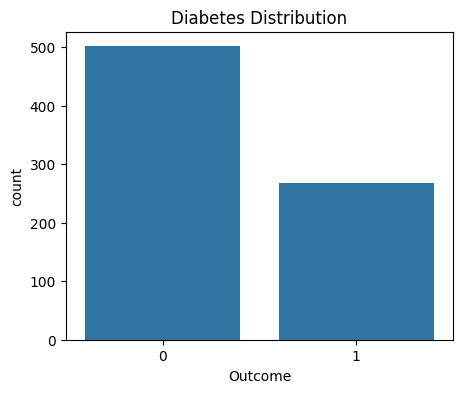

In [19]:
plt.figure(figsize=(5,4))

sns.countplot(x='Outcome',data=df)

plt.title("Diabetes Distribution")

plt.show()

Step 8: Feature Selection

In [20]:
X = df.drop("Outcome",axis=1)

y = df["Outcome"]

Step 9: Train-Test Split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Step 10: Build Decision Tree Model

In [22]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

Step 11: Predict

In [23]:
y_pred = model.predict(X_test)

Step 12: Accuracy

In [24]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy =",accuracy)

Accuracy = 0.7207792207792207


Step 13: Confusion Matrix

In [25]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[91  9]
 [34 20]]


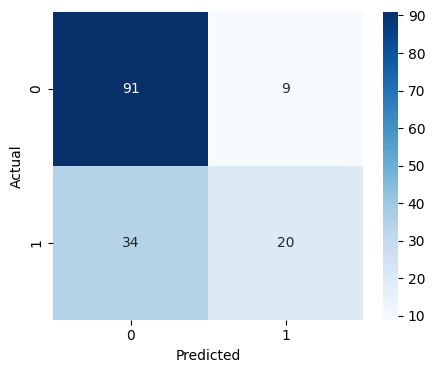

In [26]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Step 14: Classification Report

In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.91      0.81       100
           1       0.69      0.37      0.48        54

    accuracy                           0.72       154
   macro avg       0.71      0.64      0.65       154
weighted avg       0.71      0.72      0.69       154



Step 15: Visualize Decision Tree

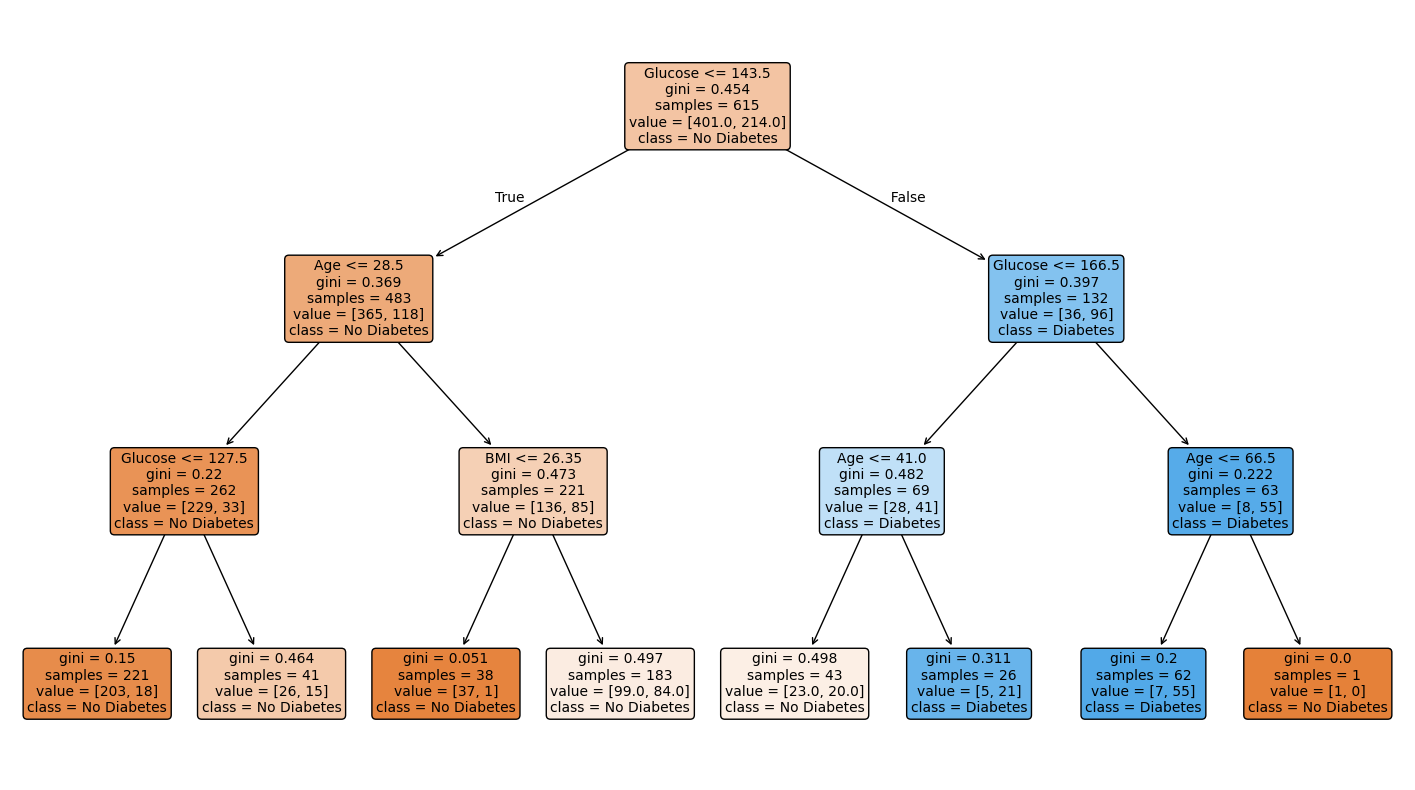

In [28]:
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Diabetes","Diabetes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

Step 17: Predict New Patient

In [31]:
new_patient = [[
    2,
    150,
    80,
    30,
    120,
    28,
    0.5,
    35
]]

prediction = model.predict(new_patient)

if prediction[0]==1:

    print("Patient is likely to have Diabetes")

else:

    print("Patient is unlikely to have Diabetes")

Patient is unlikely to have Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Diabetes Dataset
        │
        ▼
Load Dataset
        │
        ▼
Understand Dataset
        │
        ▼
Data Cleaning
        │
        ▼
Replace Missing Values
        │
        ▼
EDA
        │
        ▼
Feature Selection
        │
        ▼
Train-Test Split
        │
        ▼
Decision Tree Training
        │
        ▼
Prediction
        │
        ▼
Model Evaluation
        │
        ▼
Decision Tree Visualization
        │
        ▼
Predict New Patient